# Magnipy Tutorial

This tutorial will walk you through using some of the main functionalities of the Magnipy package, which is used to compute and compare the magnitude (effective size) of point clouds.

## Tutorial overview:
1. Import required packages
2. Generating datasets
    - Dataset #1: Random Point Cloud
    - Dataset #2: Clusters/Blobs
    - Dataset #3: Swiss roll
3. Computing magnitude functions
4. Convergence scales and evaluation intervals
5. MagArea: An intrinsic measure of diversity
6. MagDiff: Evaluating differences in diversity across datasets

### Part 1: Importing Packages
Before we begin, we must import the packages required for our functionality.

Make sure that you have activated your virtual environment and installed the dependencies using poetry before this step.

In [67]:
# import statements for external packages
from importlib import reload
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.datasets import make_swiss_roll, make_blobs, make_s_curve
from sklearn.decomposition import PCA

In [68]:
# import statements from magnipy repo
import magnipy
reload(magnipy)
from magnipy import Magnipy
from magnipy.datasets import sample_sphere

### Part 2: Generating Datasets

#### Dataset #1: Random Point Cloud

Here, we generate random points in a 3D space (i.e. selecting points according to a uniform distribution so that any point is chosen with equal probability.)

#### Dataset #2: Clusters/Blobs

Here, we generate a dataset clustered around 5 points.

#### Dataset #3: The Swiss Roll

The Swiss Roll is a classic generated dataset that roughly takes the shape of a 2D plane that has been rolled in a spiral, forming a 3D manifold. Here, we use it as a toy example to demonstrate the functionality of our magnipy package.

In [69]:
# Generate our 3D point clouds
np.random.seed(0)
n=1000
### name: [dataset, true dimension]

# Random
uni = np.random.uniform(0,1,size=(n,3)),3
uni_data = uni[0]
uni_dims = uni[1]

# Clusters/blobs
blobs = make_blobs(n, centers=5, n_features=3)[0],3
blobs_data = blobs[0]
blobs_dims = blobs[1]

# Swiss roll
sr = make_swiss_roll(n)[0], 2
sr_data = sr[0]
sr_dims = sr[1]

In [70]:
# Convert point clouds to pandas dataframe

uni_df = pd.DataFrame(uni_data, columns=['x', 'y', 'z'])
blobs_df = pd.DataFrame(blobs_data, columns=['x', 'y', 'z'])
sr_df = pd.DataFrame(sr_data, columns=['x', 'y', 'z'])

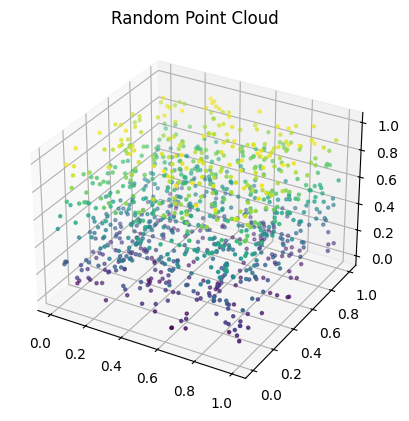

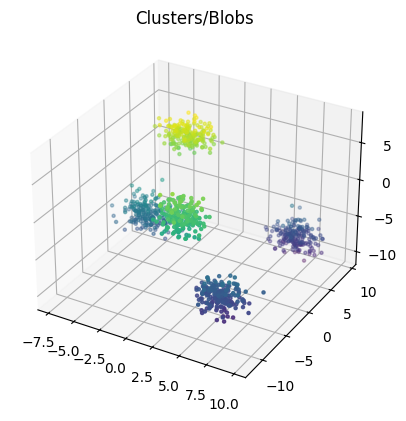

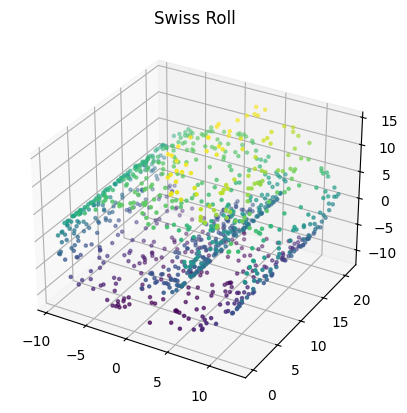

In [71]:
# Create 3D plots

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(uni_df['x'], uni_df['y'], uni_df['z'], c=uni_df['z'], cmap='viridis', marker='o', s=5)
plt.title("Random Point Cloud")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(blobs_df['x'], blobs_df['y'], blobs_df['z'], c=blobs_df['z'], cmap='viridis', marker='o', s=5)
plt.title("Clusters/Blobs")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(sr_df['x'], sr_df['y'], sr_df['z'], c=sr_df['z'], cmap='viridis', marker='o', s=5)
plt.title("Swiss Roll")
plt.show()

### Part 3: Computing Magnitude

For each dataset, we then compute the magnitude functions as follows.

We first create the Magnipy object for each datset, which we will use to call our magnitude methods.
Notice that we specify how many t values we want (**n_ts=100**) and our distance metric (**metric='euclidean'**).

Recall that **t** is our distance scaling factor. This means any pairwise distance between points is scaled by a factor of t. We can visualize an increase in t as 'zooming in', where points spread further away from each other.

When t is small (i.e. we have zoomed all the way out), the distances between points is negligible and we effectively have 1 point. As t increases and we zoom in, eventually we get to a point where all points are adequately 'spread out', at which point the magnitude reaches its maximum value: the cardinality of the dataset.

Thus, if we plot magnitude against t, we get a monotonically increasing function that begins at 1 and plateaus at the cardinality of the dataset.

In [72]:
# Creating a Magnipy object for each dataset
mags = [Magnipy(uni_data, name='random', n_ts=100, metric="euclidean", log_scale = True),
        Magnipy(blobs_data, name='clustered/blobs', n_ts=100, metric="euclidean", log_scale = True),
        Magnipy(sr_data, name='swiss roll', n_ts=100, metric="euclidean", log_scale = True)]

We can now call any of our magnitude methods on our Magnipy objects. For example, we can use the **plot_magnitude_function** to visualize how the magntiude of the datasets changes as our t value increases.

Text(0.5, 1.0, 'Plotting Magnitude with Magnipy')

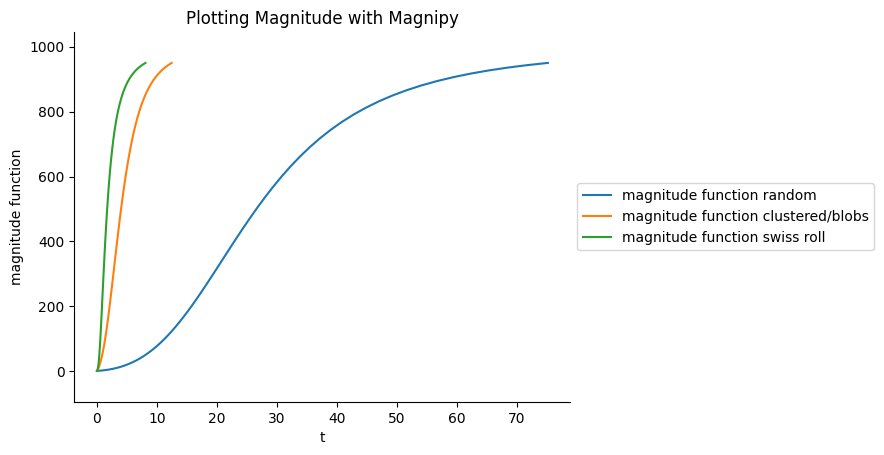

In [73]:
# Plotting magnitude
for mag in mags:
    mag.plot_magnitude_function()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.autoscale(enable=True, axis='both', tight=True)
plt.margins(x=0.05, y=0.1)  # 5% margin on x, 10% on y
plt.title("Plotting Magnitude with Magnipy")

### Part 4: Convergence Scales & Evaluation Intervals

Note, that by default, we have automatically estimated each magnitude function's domain using the approximate **convergence scale**: that is, when the magnitude has reached 0.95*|X|, or 95% of the space's cardinality.

Notice that the swiss roll and clustered/blobs datasets converge towards their cardinality much faster than that of the random dataset. Thus, we expect their convergence scales to be much lower. This idea is confirmed by the convergence scales of the three datasets.

In [74]:
# Computing convergence scales

print("Convergence Scales for Our Datasets:")
for i, Mag in enumerate(mags):
    n=Mag.get_dist().shape[0]
    # we use the .get_t_conv() method to get covergence scale for each dataset
    print(Mag.get_name().upper() + ": " + f"{Mag.get_t_conv():.2f}")

Convergence Scales for Our Datasets:
RANDOM: 75.19
CLUSTERED/BLOBS: 12.46
SWISS ROLL: 8.09


We define each function's **evaluation interval** from zero until this convergence scale. Across datasets, we can the compute the convergence scale to define a common evaluation interval across which we can compare all spaces.

### Part 5: MagArea

Finally, we introduce our metric for intrinsic diversity of each space: **MagArea**, the area under each magnitude function. The higher the MagArea, the more diverse the space.

We can use this to for comparison between datasets evaluated across the same scales of distances i.e. using the same evaluation interval. 

MagArea of RANDOM evaluated across [0.0, 75.19] equals 592.71
MagArea of CLUSTERED/BLOBS evaluated across [0.0, 75.19] equals 932.51
MagArea of SWISS ROLL evaluated across [0.0, 75.19] equals 963.57


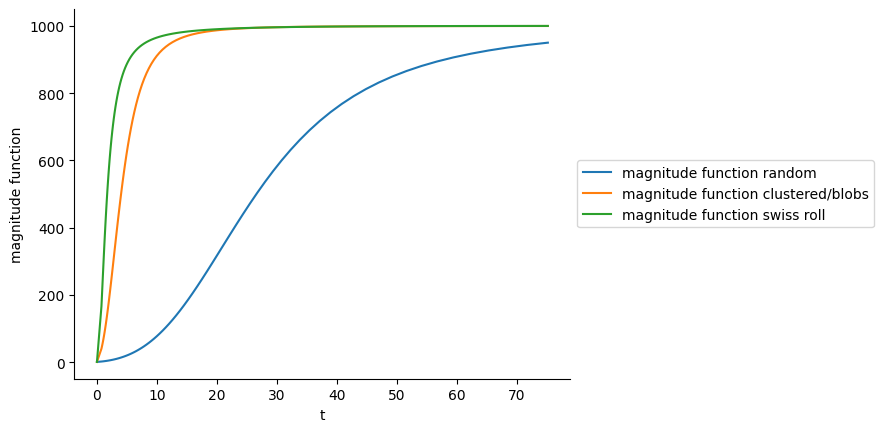

In [79]:
# Choosing same evaluation interval
t_cut = mags[0].get_t_conv()

mags2 = mags.copy()
for i, Mag in enumerate(mags2):
    Mag.change_scales(t_cut=t_cut)
    ts=Mag.get_scales()
    Mag.plot_magnitude_function()
    mag, ts = Mag.get_magnitude()
    mag_area = Mag.get_magnitude_area(absolute_area=True, scale=True, plot=False)
    print(f"MagArea of {Mag.get_name().upper()} evaluated across [{round(ts[0],2)}, {round(ts[-1],2)}] equals {round(mag_area,2)}")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

### Part 6: MagDiff

Further, we can conduct more detailed comparisons by taking MagDiff, the area between two magnitude functions, as a measure of dissimilarity.

We compare each space's magnitude to the Swiss Roll, the most diverse space with the highest magnitude, and plot the absolute MagDiff across each scale.

In [80]:
# selecting the swiss roll as a comparison point
Mag0=mags2[2]

for Mag in mags2:
    mag_diff = Mag0.get_magnitude_difference(Mag, scale=False, t_cut=t_cut, plot=True, absolute_area=False)
    print(f"MagDiff {Mag0.get_name()} - {Mag.get_name()} evaluated between [0,{round(t_cut,2)}] equals {round(mag_diff,2)}")
    plt.title("MagDiff")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

TypeError: diff_of_functions() got an unexpected keyword argument 'positive_magnitude'